In [27]:
import serial
import numpy as np
import time
from matplotlib import pyplot as plt
from ribbn_scripts.hardware_api.hardware import Exciter,Tag
import json

In [28]:
com_port1="/dev/tty.usbmodem1101"
tag1=Tag(com_port1)
print(tag1.get_mac())

com_port2="/dev/tty.usbmodem1201"
tag2=Tag(com_port2)
print(tag2.get_mac())


B4:3A:45:8A:BC:30
58:E6:C5:01:08:CC


In [29]:
tag1.queue_adc_read(690)
tag2.queue_mpp(1)

tag1.listen_esync()
tag2.listen_esync()

# One reply per tag -- reading twice just blocks until the timeout and
# raises "Stuck in read_queued". Both calls block until the exciter edge
# fires, so leave the timeout at the default 60 s rather than 10: what is
# being waited on is you triggering the exciter, not the link.
#
# tag2 runs the sweep and answers with a status line; the trace worth
# plotting is tag1's adc reply, recorded across tag2's sweep.
mpp_data  = tag1.read_queued()   # {"info":"adc",...,"data":"..."}
sweep_ack = tag2.read_queued()   # {"info":"mpp",...,"ok":1}
# The detector no longer prints the edge as it happens, so read it back.
# Comparing low_us across the two tags checks they caught the same drop.
print("tag1 edge:", tag1.esync_report())
print("tag2 edge:", tag2.esync_report())
print("tag2 sweep:", sweep_ack)


b'q:queued, adc_690\n' 	 b'q:queued, adc_690\n'
b'q:queued, mpp_1\n' 	 b'q:queued, mpp_1\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
b'esync:listening\r\n' 	 b'esync:listening\r\n'
tag1 edge: {'info': 'esync', 'edge': 'rise', 't_us': 289301794, 'low_us': 4795, 'min_mv': 0.916, 'base_mv': 231.556}
tag2 edge: {'info': 'esync', 'edge': 'rise', 't_us': 187212922, 'low_us': 2928, 'min_mv': 1.297, 'base_mv': 484.245}
tag2 sweep: {'info': 'mpp', 'ch': 8, 'passes': 1, 'ok': 1}


segment 0 [330, 390): 60 readings
segment 1 [390, 450): 60 readings
segment 2 [450, 510): 60 readings
segment 3 [510, 570): 60 readings
segment 4 [570, 630): 60 readings
segment 5 [630, 690): 60 readings


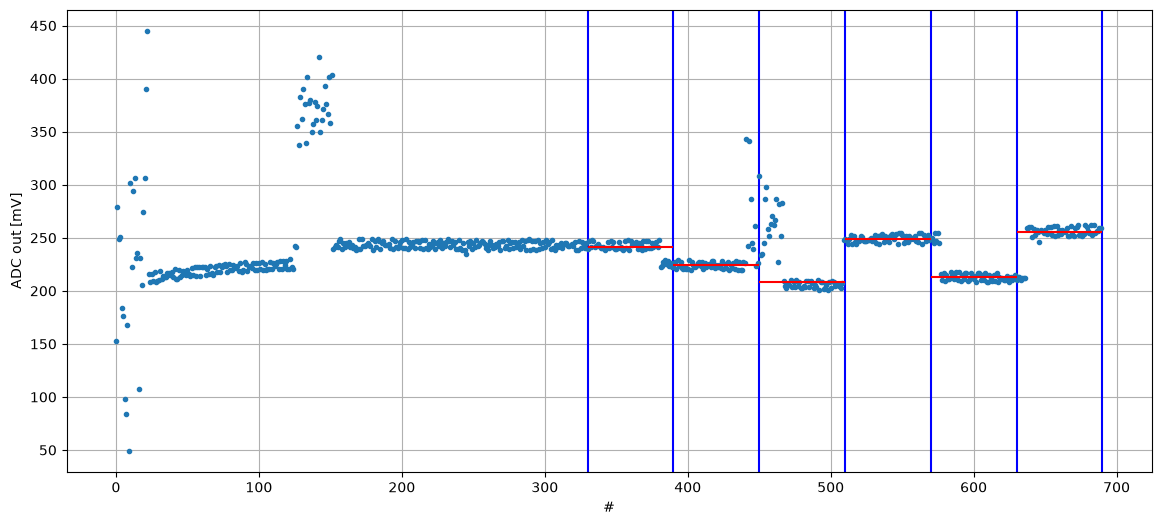

In [30]:
def plotMPPSegments(data, seg_size=60 , n_segments=6):
    """
    Plot an adc reply and split its tail into n_segments vertical segments of
    seg_size samples, counted from the back of the trace. Whatever comes before
    the first boundary is still plotted, just not segmented.
    """
    if isinstance(data, dict):
        data = data['data']
    if isinstance(data, str):
        data = list(map(float, data.split(',')))
    voltage = np.asarray(data, dtype=float)
    idx = np.arange(len(voltage))

    # Boundaries walked backwards from the last sample, then flipped so the
    # segments come out in ascending index order. Clamped at 0 for short traces.
    edges = sorted({max(len(voltage) - seg_size * i, 0) for i in range(n_segments + 1)})

    plt.figure(figsize=(14, 6))
    for e in edges:
        plt.axvline(x=e, color='b')

    plt.plot(idx, voltage, '.')

    for seg, (left, right) in enumerate(zip(edges[:-1], edges[1:])):
        in_segment = (idx >= left) & (idx < right)
        print(f"segment {seg} [{left}, {right}): {np.count_nonzero(in_segment)} readings")
        if not np.any(in_segment):
            continue
        plt.hlines(np.median(voltage[in_segment]), left, right, color='r', zorder=3)

    plt.xlabel("#")
    plt.ylabel("ADC out [mV]")
    plt.grid()
    plt.show()

plotMPPSegments(mpp_data)
